In [103]:
import pandas as pd
from pm_pd_utils import analyze_column, initial_dataframe_analysis
import seaborn as sns
import matplotlib.pyplot as plt

In [92]:
sns.set_theme(style='darkgrid')

In [2]:
PATH = 'data/ContingencyData.csv'
df_contingency = pd.read_csv(PATH, parse_dates=['timestamp'])

In [17]:
# Process df_contingency
df_contingency = df_contingency.sort_values(by=['truck_id', 'timestamp'])

In [9]:
df_contingency.dtypes.to_frame().rename(columns={0: 'dtype'})

,dtype
id,int64
fieldid,object
shiftid,int64
timestamp,datetime64[ns]
duration,int64
truck_id,object
stop_code,int64
stop_reason,object
status_id,int64
status_name,object


In [16]:
print(f'Total rows: {df_contingency.shape[0]}')
display(analyze_column(df_contingency, 'status_name').to_frame())
display(analyze_column(df_contingency, 'status_id').to_frame())

Total rows: 75300


,status_name
status_name,
Demora,37790
Efectivo,34906
Mantencion,1359
Reserva,1245


,status_id
status_id,
226,37790
224,34906
223,1359
225,1245


### What can be done here
- Join/Concat the table with the dispatch Event Log (then the fields should match)
- This df itself can be an Event Log
- Maybe augment this data with the timestamp_end = timestamp + duration and then pivot long
```python
df_contingency_augmented = df_contingency.copy()
df_contingency_augmented['timestamp_end'] = df_contingency['timestamp'] + pd.to_timedelta(df_contingency['duration'], unit='s')
```

In [18]:
df_contingency[df_contingency['status_name'] == 'Efectivo']

,id,fieldid,shiftid,timestamp,duration,truck_id,stop_code,stop_reason,status_id,status_name
70593,2402270020010506904,03:34:55,240227002,2024-02-27 12:34:55,1584,CA100,100,Efectivo,224,Efectivo
70590,2402270020011456148,04:04:09,240227002,2024-02-27 13:04:09,567,CA100,100,Efectivo,224,Efectivo
71207,2402270020013386532,04:34:17,240227002,2024-02-27 13:34:17,507,CA100,100,Efectivo,224,Efectivo
71206,2402270020013920232,04:48:46,240227002,2024-02-27 13:48:46,87,CA100,100,Efectivo,224,Efectivo
71208,2402270020014622260,05:00:33,240227002,2024-02-27 14:00:33,2521,CA100,100,Efectivo,224,Efectivo
...,...,...,...,...,...,...,...,...,...,...
68112,2403260010010358784,03:42:07,240326001,2024-03-26 00:42:07,1008,CA99,100,Efectivo,224,Efectivo
68106,2403260010011098000,04:02:20,240326001,2024-03-26 01:02:20,9550,CA99,100,Efectivo,224,Efectivo
68103,2403260010018232716,06:46:41,240326001,2024-03-26 03:46:41,1513,CA99,100,Efectivo,224,Efectivo
68105,2403260010021413184,07:51:10,240326001,2024-03-26 04:51:10,4843,CA99,100,Efectivo,224,Efectivo


In [23]:
df = df_contingency.copy()
df = df.rename(columns={'truck_id': 'case_id'}).drop(columns=['id', 'fieldid'])
# Correct the datetime for utc change in march UTC+3
df['timestamp'] = df['timestamp'] + pd.to_timedelta(3, unit='hours')
df.head()

,shiftid,timestamp,duration,case_id,stop_code,stop_reason,status_id,status_name
70594,240227002,2024-02-27 15:30:40,255,CA100,207,Pista obstruida,226,Demora
70593,240227002,2024-02-27 15:34:55,1584,CA100,100,Efectivo,224,Efectivo
70591,240227002,2024-02-27 16:01:19,170,CA100,285,Sin equipo de carguio,226,Demora
70590,240227002,2024-02-27 16:04:09,567,CA100,100,Efectivo,224,Efectivo
70592,240227002,2024-02-27 16:13:36,1241,CA100,245,Colacion en comedor,226,Demora


In [28]:
df['timediff'] = df.groupby('case_id')['timestamp'].diff().dt.total_seconds().shift(-1)
df.sample(10) # Here timediff is absolutly the same that the duration in seconds

,shiftid,timestamp,duration,case_id,stop_code,stop_reason,status_id,status_name,timediff
15478,240315001,2024-03-15 07:01:40,7,CA72,278,Operador fuera del equipo,226,Demora,7.0
20293,240316002,2024-03-16 14:33:39,1465,CA64,100,Efectivo,224,Efectivo,1465.0
11518,240304002,2024-03-04 14:21:28,106,CA83,207,Pista obstruida,226,Demora,106.0
57593,240321002,2024-03-21 13:21:37,157,CA84,207,Pista obstruida,226,Demora,157.0
15218,240315001,2024-03-15 00:13:31,1041,CA58,100,Efectivo,224,Efectivo,1041.0
63542,240324001,2024-03-24 05:35:49,4928,CA51,100,Efectivo,224,Efectivo,4928.0
48336,240313001,2024-03-13 00:00:00,4576,CA58,319,ACTIVIDAD DE SEGURIDAD,225,Reserva,4576.0
9611,240304001,2024-03-04 02:30:34,3280,CA105,100,Efectivo,224,Efectivo,3280.0
7781,240303001,2024-03-03 08:07:40,148,CA88,100,Efectivo,224,Efectivo,148.0
12636,240305001,2024-03-05 03:25:28,1212,CA50,288,COLACION EN CABINA 1,226,Demora,1212.0


<Axes: xlabel='status_name', ylabel='activity_kind'>

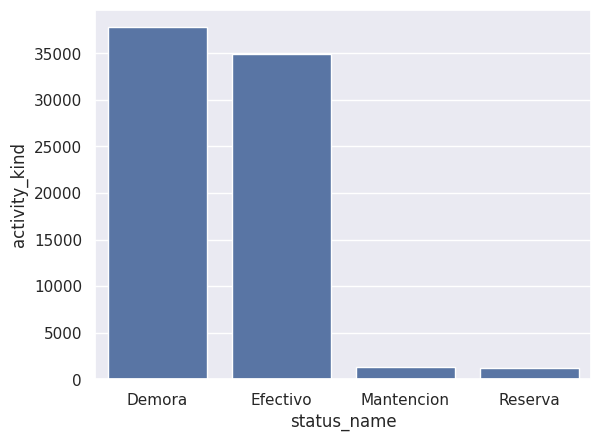

In [138]:
df_short_activity = analyze_column(df_contingency, 'status_name').to_frame().rename(columns={'status_name': 'activity_kind'}).reset_index()
sns.barplot(df_short_activity, x='status_name', y='activity_kind')

In [34]:
df[['duration', 'timediff']].dropna().sum().diff().dropna().rename(index={'timediff': 'Total difference'})

Total diference    0.0
dtype: float64

In [78]:
df_codes = df.groupby(by='stop_reason')[['stop_reason', 'timediff']].\
              agg({'stop_reason': 'count', 'timediff': 'sum'}).\
              rename(columns={'stop_reason': 'count'}).\
              reset_index().\
              sort_values(by='timediff', ascending=False)
              

In [79]:
df_codes.head()

,stop_reason,count,timediff
18,Efectivo,34903,85489285.0
30,Mecanica imprevista,517,6431019.0
29,Mantencion programada,173,4870642.0
22,Falla motor diesel,168,4150174.0
54,Sin infraestructura de apoyo,103,3268418.0


In [88]:
def replace_remaining_with_others(df: pd.DataFrame, top: int = 7) -> pd.DataFrame:
  df_replace = df.iloc[:top,:]
  others = df.iloc[top:,1:].sum(axis=0).tolist()
  return pd.concat([df_replace, pd.DataFrame(data=[['otros', *others]], columns=df.columns)])

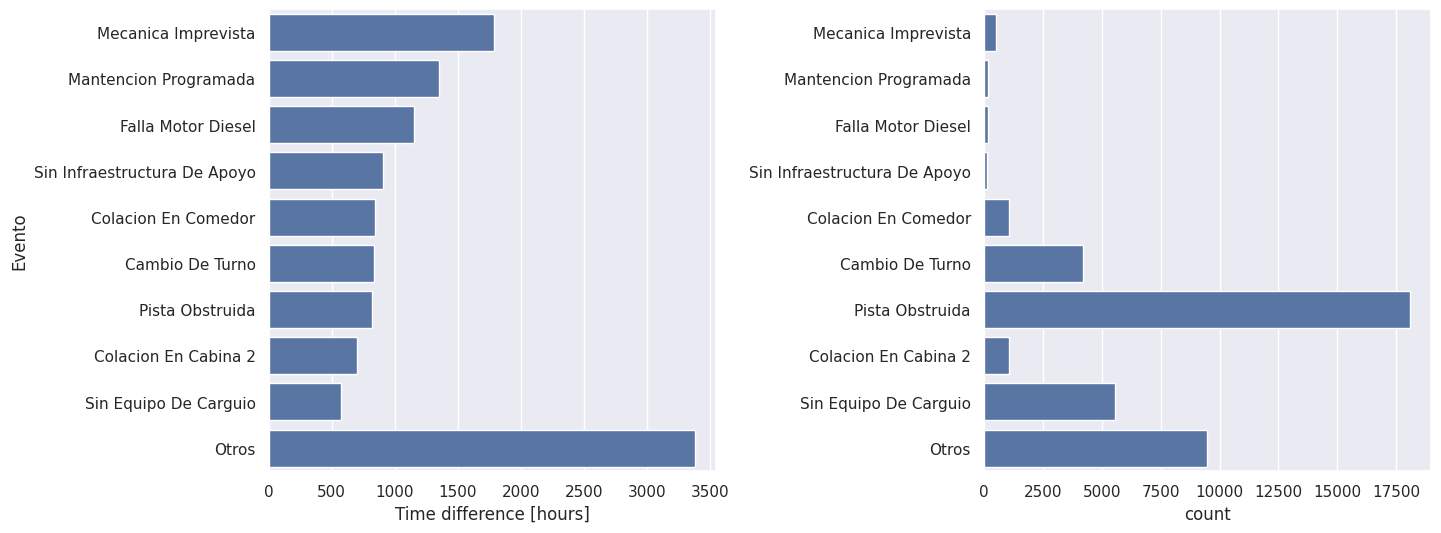

In [118]:
TOP_REASONS = 10
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(15, 6))
plt.subplots_adjust(wspace=0.6)
summary_df_event = replace_remaining_with_others(df_codes, top=TOP_REASONS).iloc[1:]
summary_df_event['timediff'] = summary_df_event['timediff'] / 3600
summary_df_event['stop_reason'] = summary_df_event['stop_reason'].str.title()
sns.barplot(summary_df_event, y='stop_reason', x='timediff', ax=ax1).set(ylabel='Evento', xlabel='Time difference [hours]')
sns.barplot(summary_df_event, y='stop_reason', x='count', ax=ax2).set(ylabel=None);

In [123]:
df_log = df.copy().rename(columns={'status_name': 'activity'}).sort_values(by=['case_id', 'timestamp']).reset_index()
common_cols = ['case_id', 'activity', 'timestamp']
df_log = df_log[[*common_cols, *(set(df_log.columns) - set(common_cols))]]
df_log.head()

,case_id,activity,timestamp,shiftid,timediff,index,status_id,stop_code,stop_reason,duration
0,CA100,Demora,2024-02-27 15:30:40,240227002,255.0,70594,226,207,Pista obstruida,255
1,CA100,Efectivo,2024-02-27 15:34:55,240227002,1584.0,70593,224,100,Efectivo,1584
2,CA100,Demora,2024-02-27 16:01:19,240227002,170.0,70591,226,285,Sin equipo de carguio,170
3,CA100,Efectivo,2024-02-27 16:04:09,240227002,567.0,70590,224,100,Efectivo,567
4,CA100,Demora,2024-02-27 16:13:36,240227002,1241.0,70592,226,245,Colacion en comedor,1241


In [224]:
df_log[df_log['case_id']== 'CA100'].tail(50)

,case_id,activity,timestamp,shiftid,timediff,index,status_id,stop_code,stop_reason,duration,case:concept:name,concept:name,time:timestamp
2084,CA100,Efectivo,2024-03-25 08:39:58+00:00,240325001,54.0,64883,224,100,Efectivo,54,CA100,Efectivo,2024-03-25 08:39:58+00:00
2085,CA100,Demora,2024-03-25 08:40:52+00:00,240325001,13.0,64884,226,202,Carga de combustible,13,CA100,Demora,2024-03-25 08:40:52+00:00
2086,CA100,Efectivo,2024-03-25 08:41:05+00:00,240325001,51.0,64885,224,100,Efectivo,51,CA100,Efectivo,2024-03-25 08:41:05+00:00
2087,CA100,Demora,2024-03-25 08:41:56+00:00,240325001,95.0,64886,226,207,Pista obstruida,95,CA100,Demora,2024-03-25 08:41:56+00:00
2088,CA100,Efectivo,2024-03-25 08:43:31+00:00,240325001,3000.0,64887,224,100,Efectivo,3000,CA100,Efectivo,2024-03-25 08:43:31+00:00
2089,CA100,Demora,2024-03-25 09:33:31+00:00,240325001,24.0,64879,226,207,Pista obstruida,24,CA100,Demora,2024-03-25 09:33:31+00:00
2090,CA100,Efectivo,2024-03-25 09:33:55+00:00,240325001,31.0,64880,224,100,Efectivo,31,CA100,Efectivo,2024-03-25 09:33:55+00:00
2091,CA100,Demora,2024-03-25 09:34:26+00:00,240325001,21.0,64881,226,207,Pista obstruida,21,CA100,Demora,2024-03-25 09:34:26+00:00
2092,CA100,Efectivo,2024-03-25 09:34:47+00:00,240325001,1717.0,64882,224,100,Efectivo,1717,CA100,Efectivo,2024-03-25 09:34:47+00:00
2093,CA100,Demora,2024-03-25 10:03:24+00:00,240325001,27.0,64878,226,207,Pista obstruida,27,CA100,Demora,2024-03-25 10:03:24+00:00


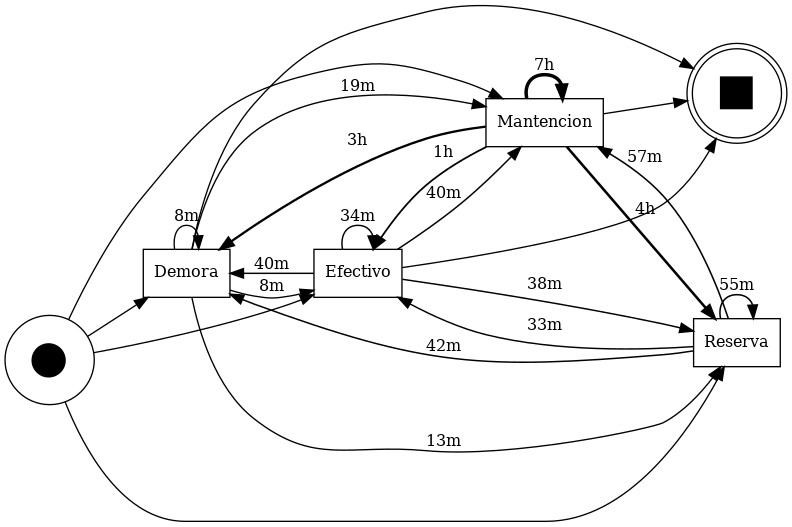

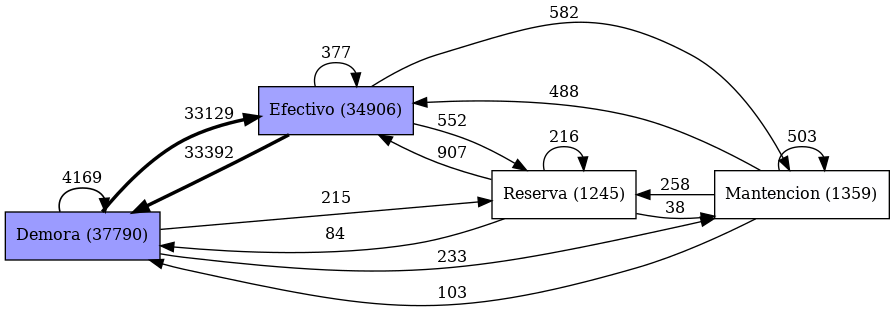

In [140]:
event_log, performance_dfg, frequency_dfg = initial_dataframe_analysis(df_log, with_dfg=True)

In [162]:
common_cols = ['start_activity', 'end_activity', 'median', 'min', 'max', 'stdev', 'sum', 'mean']
data_performance_dfg = [[*item[0], *item[1].values()] for item in dict(performance_dfg).items()]
df_performance = pd.DataFrame(data_performance_dfg, columns=common_cols)

In [169]:
df_frequency = pd.DataFrame([[*item[0], item[1]] for item in dict(frequency_dfg).items()], columns=['start_activity', 'end_activity', 'count'])
df_frequency

,start_activity,end_activity,count
0,Demora,Efectivo,33129
1,Efectivo,Demora,33392
2,Demora,Demora,4169
3,Efectivo,Mantencion,582
4,Mantencion,Efectivo,488
5,Efectivo,Efectivo,377
6,Efectivo,Reserva,552
7,Reserva,Efectivo,907
8,Reserva,Demora,84
9,Demora,Mantencion,233


In [179]:
FROM_ACTIVITY = 'Demora'
df_performance_short = df_performance[['start_activity', 'end_activity', 'mean', 'median', 'sum']]
df_performance_short['sum'] = df_performance_short['sum'] / 3600
print(f'UNIQUE ACTIVITIES: {df_performance['end_activity'].unique().tolist()}')
df_performance_short[df_performance_short['end_activity'] == FROM_ACTIVITY]

UNIQUE ACTIVITIES: ['Efectivo', 'Demora', 'Mantencion', 'Reserva']


/tmp/ipykernel_2790/642192436.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_performance_short['sum'] = df_performance_short['sum'] / 3600


,start_activity,end_activity,mean,median,sum
1,Efectivo,Demora,2456.167435,1594.0,22782.317500
2,Demora,Demora,509.441113,402.0,589.961111
8,Reserva,Demora,2557.000000,1463.5,59.663333
12,Mantencion,Demora,12772.388350,11733.0,365.432222


<Axes: xlabel='sum', ylabel='end_activity'>

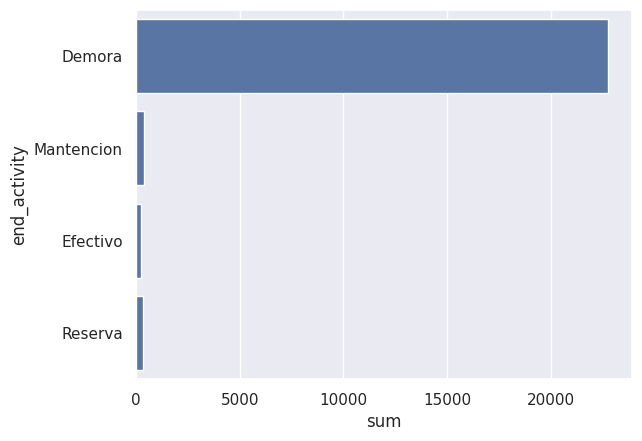

In [180]:
ACTIVITY = 'Efectivo' # One from ['Efectivo', 'Demora', 'Mantencion', 'Reserva']
METRIC = 'sum' # One from ['mean', 'median', 'count']
df_summary = df_frequency.merge(df_performance_short, on=['start_activity', 'end_activity'])
sns.barplot(df_summary[df_summary['start_activity'] == ACTIVITY], x=METRIC, y='end_activity')

In [204]:
df_log[df_log['activity'] == 'Reserva']

,case_id,activity,timestamp,shiftid,timediff,index,status_id,stop_code,stop_reason,duration,case:concept:name,concept:name,time:timestamp
466,CA100,Reserva,2024-03-03 04:25:57+00:00,240303001,922.0,6378,225,315,CON OPERADOR NO REQUERIDO,922,CA100,Reserva,2024-03-03 04:25:57+00:00
574,CA100,Reserva,2024-03-04 11:09:01+00:00,240304001,2915.0,10139,225,315,CON OPERADOR NO REQUERIDO,2915,CA100,Reserva,2024-03-04 11:09:01+00:00
701,CA100,Reserva,2024-03-06 15:27:43+00:00,240306002,2777.0,33266,225,315,CON OPERADOR NO REQUERIDO,2777,CA100,Reserva,2024-03-06 15:27:43+00:00
723,CA100,Reserva,2024-03-07 08:26:01+00:00,240307001,5084.0,34971,225,314,SIN OPERADOR / FUERA DE FAENA,5084,CA100,Reserva,2024-03-07 08:26:01+00:00
764,CA100,Reserva,2024-03-08 00:01:43+00:00,240308001,12.0,36665,225,231,PALA NO DISPONIBLE,12,CA100,Reserva,2024-03-08 00:01:43+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74813,CA99,Reserva,2024-03-17 12:00:00+00:00,240317002,1763.0,479,225,307,MP10 alto,1763,CA99,Reserva,2024-03-17 12:00:00+00:00
74968,CA99,Reserva,2024-03-20 10:23:24+00:00,240320001,1858.0,53468,225,315,CON OPERADOR NO REQUERIDO,1858,CA99,Reserva,2024-03-20 10:23:24+00:00
74978,CA99,Reserva,2024-03-20 15:30:13+00:00,240320002,906.0,55244,225,315,CON OPERADOR NO REQUERIDO,906,CA99,Reserva,2024-03-20 15:30:13+00:00
75039,CA99,Reserva,2024-03-21 14:40:20+00:00,240321002,4460.0,57431,225,315,CON OPERADOR NO REQUERIDO,4460,CA99,Reserva,2024-03-21 14:40:20+00:00


In [192]:
df_activity_reason = df_log.groupby(by=['activity', 'stop_reason'])[['activity', 'stop_reason']].\
                            count().\
                            drop(columns=['activity']).\
                            rename(columns={'stop_reason': 'count'}).\
                            reset_index()                            
df_activity_reason.sample(10)

,activity,stop_reason,count
31,Mantencion,Mant. Prog. Motor diesel,12
41,Mantencion,Reparacion equipo accidentado,17
36,Mantencion,PRESURIZACION NEUMATICO NO PR,10
56,Reserva,MP10 alto,123
4,Demora,Colacion en comedor,1047
44,Mantencion,SISTEMA CAS,6
50,Mantencion,TORQUE NEUMATICO,27
20,Mantencion,ACCIDENTE,3
58,Reserva,Restriccion Planta,1
39,Mantencion,Radiocomunicacion,6


Possible values: ['Demora', 'Efectivo', 'Mantencion', 'Reserva']


[Text(0.5, 1.0, 'Actividades de Mantención'),
 Text(0, 0.5, 'Razón de Interrupción'),
 Text(0.5, 0, 'Frecuencia')]

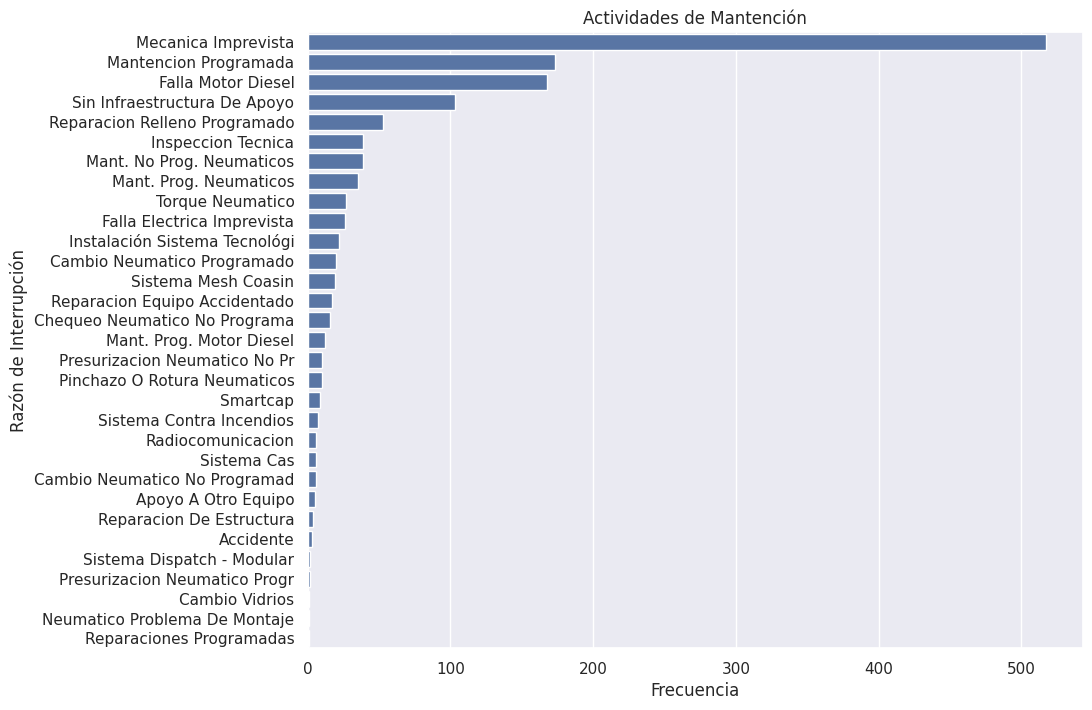

In [201]:
print(f'Possible values: {df_activity_reason['activity'].unique().tolist()}')
df_act_sort = df_activity_reason.sort_values(by=['count'], ascending=False)
df_act_sort['stop_reason'] = df_act_sort['stop_reason'].str.title()
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))
ax = sns.barplot(df_act_sort[df_act_sort['activity'] == 'Mantencion'], x='count', y='stop_reason')
ax.set(title="Actividades de Mantención", ylabel="Razón de Interrupción", xlabel="Frecuencia");

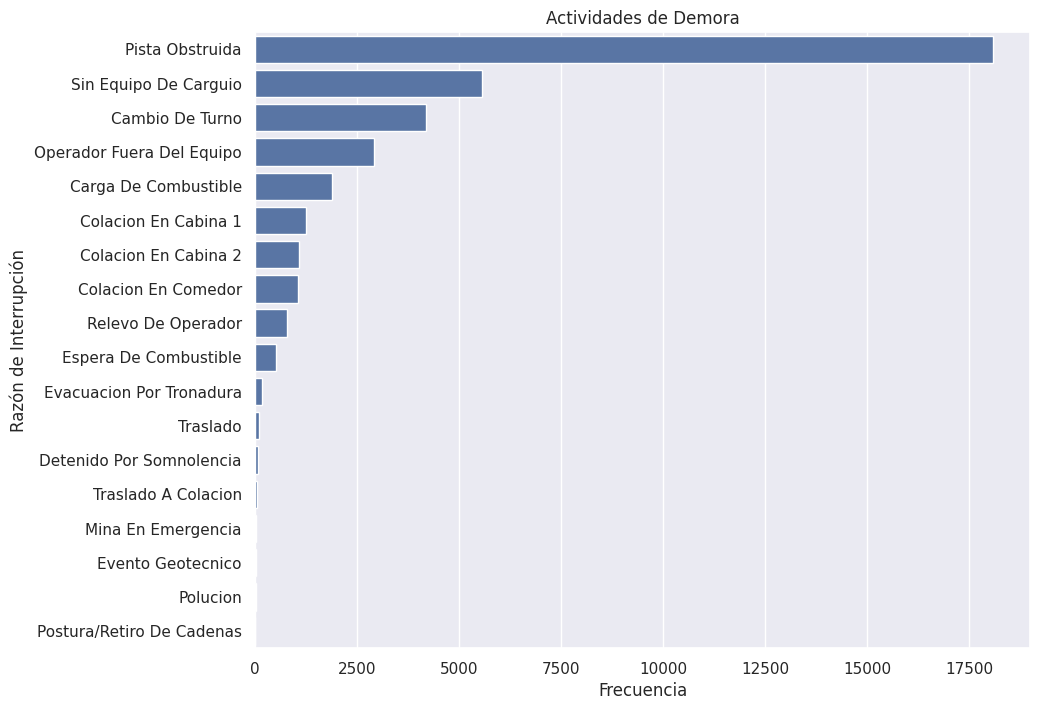

In [221]:
def group_and_plot_by_activity(df, activity):
  df_act_sort = df.sort_values(by=['count'], ascending=False)
  df_act_sort['stop_reason'] = df_act_sort['stop_reason'].str.title()
  fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))
  ax = sns.barplot(df_act_sort[df_act_sort['activity'] == activity], x='count', y='stop_reason')
  ax.set(title=f"Actividades de {activity}", ylabel="Razón de Interrupción", xlabel="Frecuencia")
  return fig

group_and_plot_by_activity(df_activity_reason, 'Demora');

In [215]:
print(f'Total horas {df_log['timediff'].sum() / 3600:.2f}')
print(f'Total horas {df_log[df_log['activity'] != 'Efectivo']['timediff'].sum() / 3600:.2f}')

Total horas 36097.92
Total horas 12349.83
